# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 11**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 11.4 Principal Component Analysis – Exercises
## Exercise 1 – Why are Maggie's properties not selling?
Approach: (1) compare two groups of properties, (2) use **PCA** to find the main dimensions along which the listings differ, (3) confirm the drivers with a model.

> **Dataset – House Sales in King County, USA (Kaggle: `harlfoster/housesalesprediction`, file `kc_house_data.csv`).**
> Link: <https://www.kaggle.com/datasets/harlfoster/housesalesprediction>
> **Records:** 21,613 real house sales (May 2014 – May 2015) · **Features (12):** `sqft_living`, `sqft_lot`, `bedrooms`, `bathrooms`, `floors`, `waterfront`, `view`, `condition`, `grade`, `age_years` (= 2015 − `yr_built`), `sqft_basement`, `sqft_living15` · **Outcome:** `high_price` = 1 if `price` is above the county median ($450,000).
> **Preprocessing:** `id`, `date`, `zipcode`, `lat`, `long`, `yr_renovated` and `sqft_lot15` dropped (location is therefore *not* part of the analysis); `age_years` derived; all features standardised before PCA. No missing values.
> **Caveat:** this dataset contains *sold* homes only – there is **no sold / unsold flag**. The closest real signal is the sale price, so the analysis asks *which property characteristics separate high-priced from lower-priced homes and how PCA summarises them*; re-run it on Maggie's own listings (with a sold/unsold column) to answer her exact question.

In [45]:
kc = load_data("kc_house_data.csv",
               "https://raw.githubusercontent.com/Shreyas3108/house-price-prediction/master/kc_house_data.csv")
props = pd.DataFrame({
    "price_k":       kc["price"] / 1000,                 # used only to define the outcome, not as a feature
    "sqft_living":   kc["sqft_living"],
    "sqft_lot":      kc["sqft_lot"],
    "bedrooms":      kc["bedrooms"],
    "bathrooms":     kc["bathrooms"],
    "floors":        kc["floors"].astype(float),
    "waterfront":    kc["waterfront"],
    "view":          kc["view"],
    "condition":     kc["condition"],
    "grade":         kc["grade"],
    "age_years":     2015 - kc["yr_built"],
    "sqft_basement": kc["sqft_basement"],
    "sqft_living15": kc["sqft_living15"],
})
props["high_price"] = (props["price_k"] > props["price_k"].median()).astype(int)

print(props.shape, "| nulls:", props.isnull().sum().sum())
print(f"High-priced (above the median of ${props.price_k.median():,.0f}k): {props.high_price.mean():.1%}")
props.head()

(21613, 14) | nulls: 0
High-priced (above the median of $450k): 49.7%


,price_k,sqft_living,sqft_lot,bedrooms,bathrooms,floors,waterfront,view,condition,grade,age_years,sqft_basement,sqft_living15,high_price
0,221.9,1180,5650,3,1.00,1.0,0,0,3,7,60,0,1340,0
1,538.0,2570,7242,3,2.25,2.0,0,0,3,7,64,400,1690,1
2,180.0,770,10000,2,1.00,1.0,0,0,3,6,82,0,2720,0
3,604.0,1960,5000,4,3.00,1.0,0,0,5,7,50,910,1360,1
4,510.0,1680,8080,3,2.00,1.0,0,0,3,8,28,0,1800,1


In [46]:
# Step 1 – compare the two groups of properties
comp = props.groupby("high_price").mean().T
comp.columns = ["Lower-priced", "High-priced"]
comp["High - Lower"] = comp["High-priced"] - comp["Lower-priced"]
comp.round(2)

,Lower-priced,High-priced,High - Lower
price_k,318.97,763.57,444.60
sqft_living,1623.50,2541.18,917.68
sqft_lot,11627.44,18623.72,6996.27
bedrooms,3.13,3.61,0.49
bathrooms,1.81,2.42,0.61
floors,1.37,1.62,0.26
waterfront,0.00,0.01,0.01
view,0.07,0.40,0.33
condition,3.39,3.43,0.05
grade,7.05,8.27,1.22


In [47]:
# Step 2 – PCA on standardised features
from sklearn.decomposition import PCA

feat = [c for c in props.columns if c not in ("price_k", "high_price")]
Xs = StandardScaler().fit_transform(props[feat])

pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print("Explained variance ratio :", evr.round(3))
print("Cumulative               :", evr.cumsum().round(3))

loadings = pd.DataFrame(pca.components_[:3].T, index=feat, columns=["PC1", "PC2", "PC3"])
print("\nLoadings of the first 3 principal components:")
loadings.round(3)

Explained variance ratio : [0.349 0.158 0.106 0.084 0.066 0.056 0.047 0.045 0.037 0.021 0.02  0.01 ]
Cumulative               : [0.349 0.507 0.613 0.697 0.763 0.819 0.867 0.912 0.949 0.969 0.99  1.   ]

Loadings of the first 3 principal components:


,PC1,PC2,PC3
sqft_living,0.445,0.149,-0.109
sqft_lot,0.080,0.054,0.077
bedrooms,0.289,0.152,-0.358
bathrooms,0.423,-0.037,-0.096
floors,0.265,-0.402,0.143
waterfront,0.068,0.233,0.673
view,0.159,0.360,0.522
condition,-0.094,0.408,-0.220
grade,0.419,-0.043,0.037
age_years,-0.267,0.422,-0.058


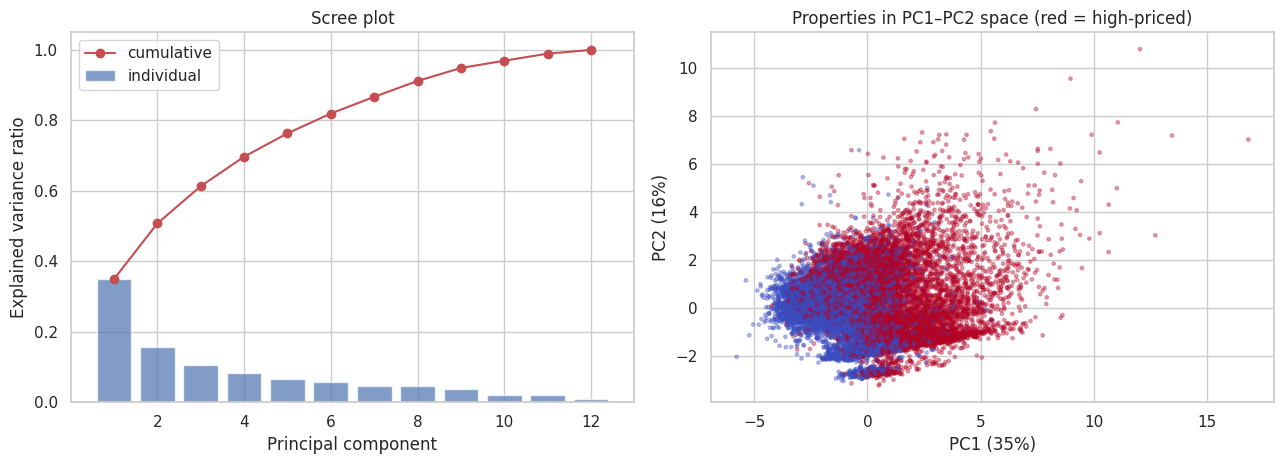

Mean component score per group:
               PC1   PC2   PC3
Lower-priced -1.01 -0.23  0.02
High-priced   1.02  0.24 -0.02


In [48]:
scores = pca.transform(Xs)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].bar(range(1, len(evr) + 1), evr, alpha=0.7, label="individual"); ax[0].plot(range(1, len(evr) + 1), evr.cumsum(), "r-o", label="cumulative")
ax[0].set(title="Scree plot", xlabel="Principal component", ylabel="Explained variance ratio"); ax[0].legend()

ax[1].scatter(scores[:, 0], scores[:, 1], c=props["high_price"], cmap="coolwarm", s=6, alpha=0.35)
ax[1].set(title="Properties in PC1–PC2 space (red = high-priced)", xlabel=f"PC1 ({evr[0]:.0%})", ylabel=f"PC2 ({evr[1]:.0%})")
plt.tight_layout(); plt.show()

# how strongly does each component separate the two groups? (mean score per group)
sep = pd.DataFrame(scores[:, :3], columns=["PC1", "PC2", "PC3"]).groupby(props["high_price"].values).mean()
sep.index = ["Lower-priced", "High-priced"]
print("Mean component score per group:"); print(sep.round(2).to_string())

5-fold CV accuracy: 0.817


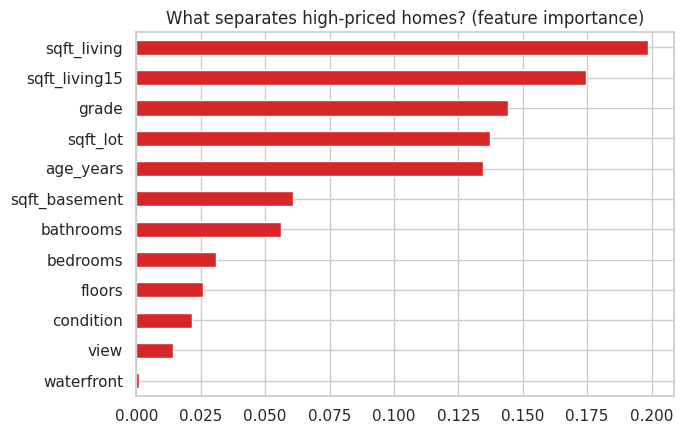

sqft_living      0.199
sqft_living15    0.175
grade            0.144
sqft_lot         0.137
age_years        0.135
sqft_basement    0.061
bathrooms        0.056
bedrooms         0.031
floors           0.026
condition        0.022
view             0.014
waterfront       0.001


In [49]:
# Step 3 – which features actually drive "high price"?  (Random Forest importance + cross-validation)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
print(f"5-fold CV accuracy: {cross_val_score(rf, props[feat], props['high_price'], cv=5).mean():.3f}")
rf.fit(props[feat], props["high_price"])

imp = pd.Series(rf.feature_importances_, index=feat).sort_values()
imp.plot.barh(color="tab:red", figsize=(7, 4.5), title="What separates high-priced homes? (feature importance)")
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3).to_string())

### Insights for Maggie
| Finding (from the tables/plots above) | What it means |
|---|---|
| **Size and build quality separate high-priced from lower-priced homes** – high-priced homes average ≈ 2,541 sq ft of living space vs ≈ 1,624 (+57 %), a construction `grade` of 8.3 vs 7.1, 2.4 vs 1.8 bathrooms and far more views (0.40 vs 0.07). | Buyers in the upper price band expect a large, well-built house; a listing that is small or low-grade for its asking price is hard to justify. |
| **PCA structure** – PC1 (≈ 35 % of variance) is a *size / quality* axis (`sqft_living` 0.45, `bathrooms` 0.42, `grade` 0.42, `sqft_living15` 0.39) and it is the only component that separates the groups (mean score −1.01 vs +1.02). PC2 (≈ 16 %) contrasts *older, basement-heavy, higher-condition* homes with *multi-storey* ones, and PC3 (≈ 11 %) is *waterfront / view*; neither separates the groups on average. Eight components are needed to keep ≈ 91 % of the variance. | The listings vary mainly in *how big and well built they are*; a single component (PC1) already summarises most of what makes a home “premium”. |
| **Random-forest check** – 5-fold CV accuracy ≈ 0.82; the most important features are `sqft_living` (≈ 0.20), `sqft_living15` (≈ 0.18) and `grade` (≈ 0.14). `condition` (≈ 0.02) and `waterfront` (≈ 0.00) matter little here. | Confirms the PCA reading: size and grade dominate. Waterfront homes are rare (< 1 % of sales), so their low importance reflects rarity, not low value. |
| **Age and condition barely differ** – average age ≈ 43 vs 45 years and condition score 3.43 vs 3.39. | Cosmetic condition or age alone is not what puts a home in a different price band in this data. |

**Recommendation:** compare each stale listing's size and grade with the comparable sales *in the same price band*; if the house is smaller or lower-grade than those comparables, the asking price – not the marketing – is the likely obstacle, so re-price rather than spend on cosmetic work.
*(Caveat: this dataset has no sold / unsold flag and no location variables in the analysis, so these are drivers of **price band**, used as a stand-in. Re-run the notebook on Maggie's own listings with a sold / unsold column to obtain her actual drivers.)*

## Exercise 2 – Identify which variable is the principal component
The table gives the **loadings** (weights) of nine variables on the first three components. A variable is a *significant contributor* to a component when its absolute loading is large (rule of thumb: |loading| ≥ 0.5 – the values highlighted in bold in the exercise).

In [50]:
load = pd.DataFrame({
    "PC1": [0.190, 0.544, 0.782, 0.365, 0.585, 0.394, 0.985, 0.520, 0.142],
    "PC2": [0.017, 0.020, -0.605, 0.294, 0.085, -0.273, 0.126, 0.402, 0.150],
    "PC3": [0.207, 0.204, 0.144, 0.585, 0.234, 0.027, -0.111, 0.519, 0.239],
}, index=["Climate", "Housing", "Health", "Crime", "Transportation", "Education", "Arts", "Recreation", "Economy"])
load.index.name = "Variable"

# Highlight |loading| >= 0.5 and find the dominant variable of each component
print("Dominant variable in each component (largest |loading|):")
for pc in load.columns:
    v = load[pc].abs().idxmax()
    print(f"  {pc}: {v:<15} loading = {load.loc[v, pc]:+.3f}")

print("\nVariables with |loading| >= 0.5:")
for pc in load.columns:
    sig = load.index[load[pc].abs() >= 0.5].tolist()
    print(f"  {pc}: {sig}")

load.style.map(lambda v: "font-weight:bold;background-color:#fde68a" if abs(v) >= 0.5 else "").format("{:.3f}")

Dominant variable in each component (largest |loading|):
  PC1: Arts            loading = +0.985
  PC2: Health          loading = -0.605
  PC3: Crime           loading = +0.585

Variables with |loading| >= 0.5:
  PC1: ['Housing', 'Health', 'Transportation', 'Arts', 'Recreation']
  PC2: ['Health']
  PC3: ['Crime', 'Recreation']


,PC1,PC2,PC3
Variable,,,
Climate,0.190,0.017,0.207
Housing,0.544,0.020,0.204
Health,0.782,-0.605,0.144
Crime,0.365,0.294,0.585
Transportation,0.585,0.085,0.234
Education,0.394,-0.273,0.027
Arts,0.985,0.126,-0.111
Recreation,0.520,0.402,0.519
Economy,0.142,0.150,0.239


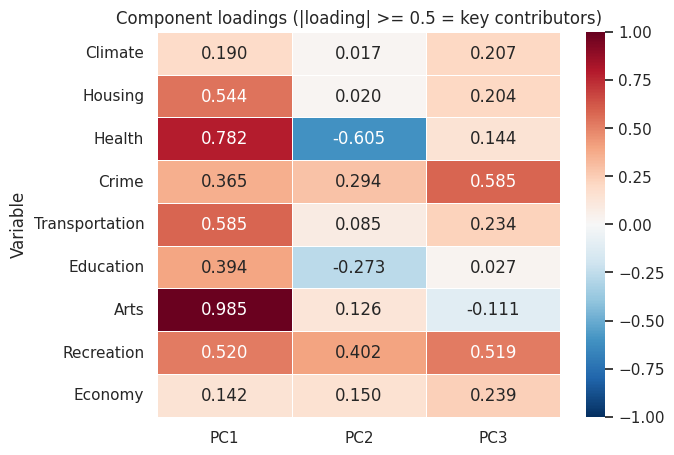

Variable
Arts              0.998
Health            0.998
Recreation        0.701
Crime             0.562
Transportation    0.404
Housing           0.338
Education         0.230
Economy           0.100
Climate           0.079


In [51]:
plt.figure(figsize=(6.5, 5))
sns.heatmap(load, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Component loadings (|loading| >= 0.5 = key contributors)"); plt.show()

# Sum of squared loadings on PC1..PC3 – overall importance of each variable in these 3 components
print((load ** 2).sum(axis=1).sort_values(ascending=False).round(3).rename("sum of squared loadings").to_string())


### Interpretation
* **PC1** – dominated by **Arts (0.985)**; Health (0.782), Transportation (0.585), Housing (0.544) and Recreation (0.520) also load strongly. PC1 is essentially a *cultural / urban-amenities* component, and **Arts is the variable that best represents the first principal component**.
* **PC2** – only **Health (−0.605)** passes the 0.5 cut-off; it is contrasted with Recreation (+0.402) and Crime (+0.294), so PC2 is a *health vs. recreation* contrast.
* **PC3** – **Crime (0.585)** and **Recreation (0.519)** are the key variables.
* **Climate** and **Economy** have small loadings on all three components (sum of squares ≈ 0.08 and 0.10) – these three components hardly represent them, while **Arts** and **Health** are almost completely explained (≈ 0.998).

> A principal component is a *linear combination of all variables*, not one variable; the variables with the largest |loading| are the ones that "define" it.
